In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pickle
from nltk.tokenize import word_tokenize
import nltk
import fasttext.util

# Download the NLTK punkt tokenizer (if not already downloaded)
nltk.download('punkt')

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string for the file path
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
print("Tokenizing text data...")
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Step 2: Load pre-trained FastText model
print("Loading FastText model...")
fasttext.util.download_model('en', if_exists='ignore')  # Download English model if not already present
ft_model = fasttext.load_model('cc.en.300.bin')  # 300-dimensional vectors

# Step 3: Convert text data to numeric features using FastText
print("Converting text data to numeric features...")
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]  # Target labels

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Initialize and train the Logistic Regression model
print("Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Step 6: Save the trained Logistic Regression model
model_path = r"C:\Users\PC\Downloads\LogisticRegression_model_fasttext.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)
print(f"Trained Logistic Regression model saved to {model_path}")

# Step 7: Evaluate the Logistic Regression model
y_pred_lr = lr_model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

# Print metrics in the desired format
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")
print(f"Logistic Regression Precision: {precision * 100:.2f}%")
print(f"Logistic Regression Recall: {recall * 100:.2f}%")
print(f"Logistic Regression F1 Score: {f1 * 100:.2f}%")

# Print detailed classification report (optional)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_lr))


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenizing text data...
Loading FastText model...
Converting text data to numeric features...
Training Logistic Regression model...
Trained Logistic Regression model saved to C:\Users\PC\Downloads\LogisticRegression_model_fasttext.pkl
Logistic Regression Accuracy: 89.42%
Logistic Regression Precision: 89.56%
Logistic Regression Recall: 89.42%
Logistic Regression F1 Score: 89.41%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89     23238
           1       0.87      0.92      0.90     23171

    accuracy                           0.89     46409
   macro avg       0.90      0.89      0.89     46409
weighted avg       0.90      0.89      0.89     46409



[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenizing text data...
Loading FastText model...
Converting text data to numeric features...
Training Logistic Regression model...
Trained Logistic Regression model saved to C:\Users\PC\Downloads\LogisticRegression_model_fasttext.pkl

Confusion Matrix:


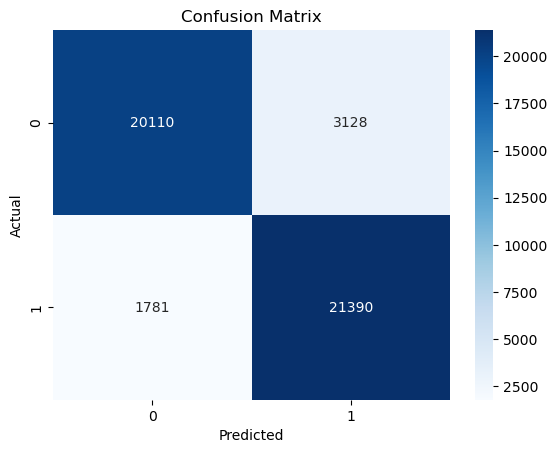


ROC Curve:


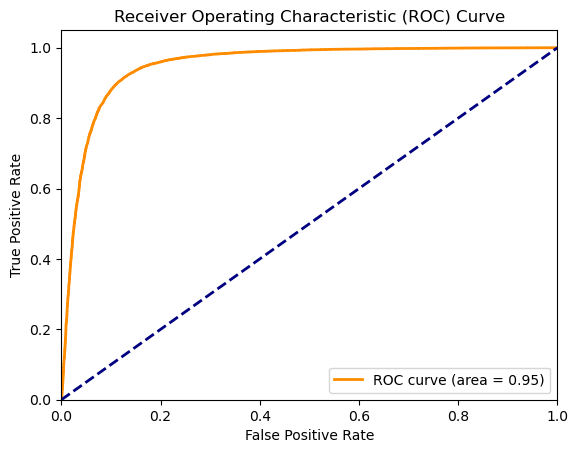

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
from nltk.tokenize import word_tokenize
import nltk
import fasttext.util

# Download the NLTK punkt tokenizer (if not already downloaded)
nltk.download('punkt')

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string for the file path
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
print("Tokenizing text data...")
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Step 2: Load pre-trained FastText model
print("Loading FastText model...")
fasttext.util.download_model('en', if_exists='ignore')  # Download English model if not already present
ft_model = fasttext.load_model('cc.en.300.bin')  # 300-dimensional vectors

# Step 3: Convert text data to numeric features using FastText
print("Converting text data to numeric features...")
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]  # Target labels

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Initialize and train the Logistic Regression model
print("Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Step 6: Save the trained Logistic Regression model
model_path = r"C:\Users\PC\Downloads\LogisticRegression_model_fasttext.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)
print(f"Trained Logistic Regression model saved to {model_path}")

# Step 7: Evaluate the Logistic Regression model
y_pred_lr = lr_model.predict(X_test)

# Confusion Matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
print("\nROC Curve:")
if len(np.unique(y_test)) == 2:  # Binary classification
    y_prob = lr_model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()
else:
    print("ROC curve is only applicable for binary classification.")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Tokenizing text data...
Loading FastText model...
Converting text data to numeric features...
Training Logistic Regression model...
Trained Logistic Regression model saved to C:\Users\PC\Downloads\LogisticRegression_model_fasttext.pkl

Error Metrics:


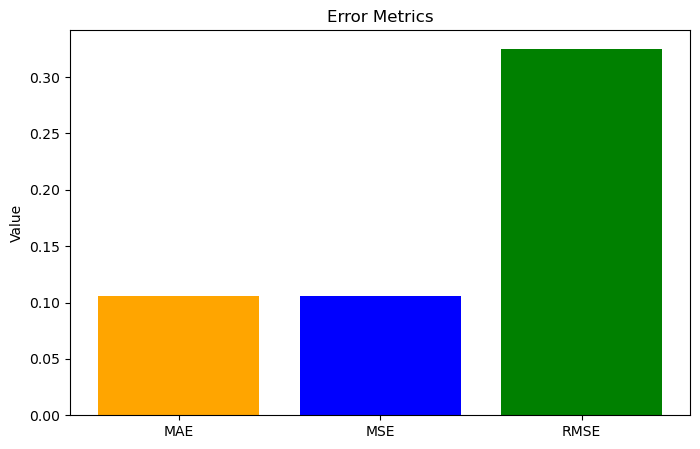

MAE: 0.10577689672261846
MSE: 0.10577689672261846
RMSE: 0.32523360331094087


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import pickle
from nltk.tokenize import word_tokenize
import nltk
import fasttext.util

# Download the NLTK punkt tokenizer (if not already downloaded)
nltk.download('punkt')

# Load your preprocessed dataset
data_path = r"C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx"  # Use raw string for the file path
data = pd.read_excel(data_path)

# Replace with the actual column names in your dataset
text_column = 'cleaned_text'  # Column containing the cleaned text data
target_column = 'encoded_class'  # Column containing the target labels

# Ensure no missing values in the text column
data[text_column] = data[text_column].fillna("missing")

# Step 1: Tokenize the text data
print("Tokenizing text data...")
tokenized_texts = [word_tokenize(text.lower()) for text in data[text_column]]

# Step 2: Load pre-trained FastText model
print("Loading FastText model...")
fasttext.util.download_model('en', if_exists='ignore')  # Download English model if not already present
ft_model = fasttext.load_model('cc.en.300.bin')  # 300-dimensional vectors

# Step 3: Convert text data to numeric features using FastText
print("Converting text data to numeric features...")
def text_to_avg_vector(tokens):
    vectors = [ft_model.get_word_vector(word) for word in tokens]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(ft_model.get_dimension())

X = np.array([text_to_avg_vector(tokens) for tokens in tokenized_texts])
y = data[target_column]  # Target labels

# Step 4: Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Initialize and train the Logistic Regression model
print("Training Logistic Regression model...")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Step 6: Save the trained Logistic Regression model
model_path = r"C:\Users\PC\Downloads\LogisticRegression_model_fasttext.pkl"  # File path to save the model
with open(model_path, 'wb') as f:
    pickle.dump(lr_model, f)
print(f"Trained Logistic Regression model saved to {model_path}")

# Step 7: Evaluate the Logistic Regression model
y_pred_lr = lr_model.predict(X_test)

# MAE, MSE, RMSE
print("\nError Metrics:")
mae = mean_absolute_error(y_test, y_pred_lr)
mse = mean_squared_error(y_test, y_pred_lr)
rmse = np.sqrt(mse)

# Plotting Error Metrics
metrics = ['MAE', 'MSE', 'RMSE']
values = [mae, mse, rmse]
colors = ['orange', 'blue', 'green']

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=colors)
plt.title('Error Metrics')
plt.ylabel('Value')
plt.show()

print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")


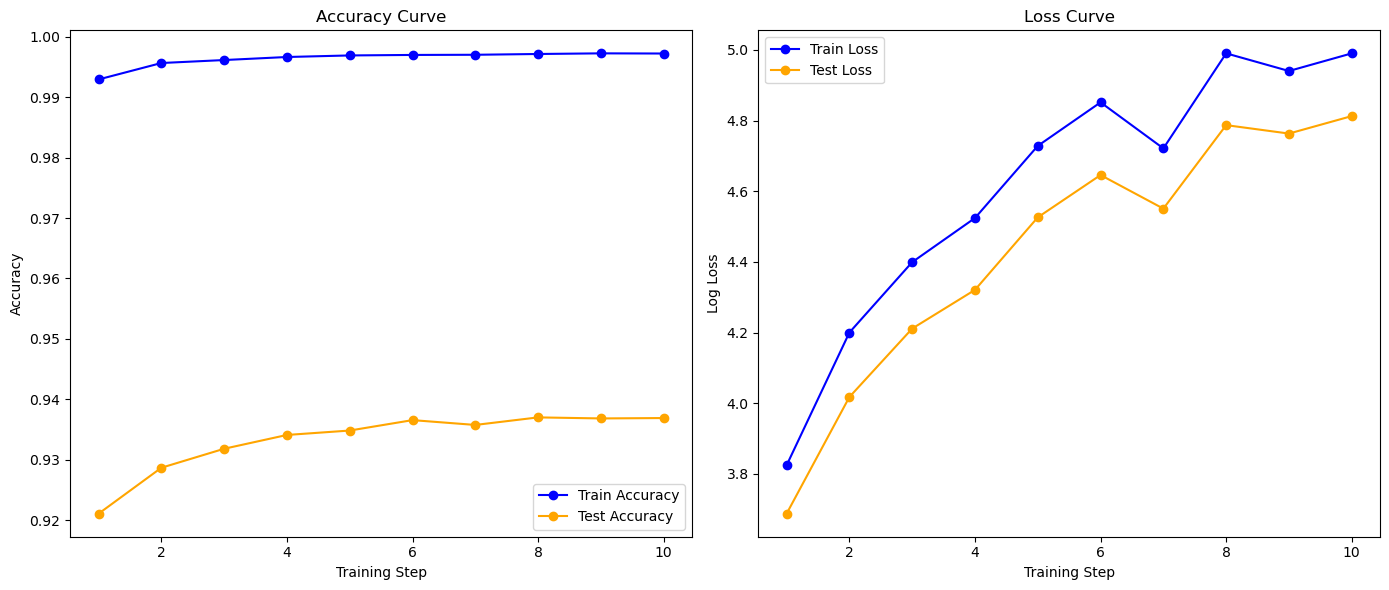

In [9]:
import pandas as pd
import fasttext
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
import matplotlib.pyplot as plt

# Load your dataset
data = pd.read_excel(r'C:\Users\PC\OneDrive\Desktop\your_preprocessed_data.xlsx')  # Use raw string to handle backslashes

# Handle missing values by filling NaNs with an empty string (or use dropna as mentioned earlier)
data['cleaned_text'] = data['cleaned_text'].fillna('')

# Assuming 'cleaned_text' is your feature column and 'encoded_class' is your target column
X = data['cleaned_text']  # Feature column
y = data['encoded_class']  # Target column

# Split the data into training and testing sets
X_train_ft, X_test_ft, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Save the training data to a temporary file for fastText
train_data = pd.DataFrame({'text': X_train_ft, 'label': y_train})
train_data['label'] = train_data['label'].apply(lambda x: f'__label__{x}')  # Format labels as fastText requires
train_data.to_csv('train_data.txt', index=False, header=False, sep='\t')

# Save the test data to a temporary file for fastText
test_data = pd.DataFrame({'text': X_test_ft, 'label': y_test})
test_data['label'] = test_data['label'].apply(lambda x: f'__label__{x}')  # Format labels as fastText requires
test_data.to_csv('test_data.txt', index=False, header=False, sep='\t')

# Define number of steps for incremental training (simulation)
num_steps = 10
step_size = len(X_train_ft) // num_steps

# Initialize lists to store accuracy and loss at each step
train_accuracies = []
test_accuracies = []
train_losses = []
test_losses = []

# Initialize fastText model
clf = None

# Simulate the training process by splitting into steps
for step in range(1, num_steps + 1):
    # Get the subset of the data for this step
    end_index = step * step_size
    subset_train_data = train_data[:end_index]
    subset_train_data.to_csv('train_data_step.txt', index=False, header=False, sep='\t')

    # Train the fastText model on the current subset of data with adjusted parameters to prevent overfitting
    clf = fasttext.train_supervised(input='train_data_step.txt', epoch=10, lr=0.1, wordNgrams=2, dim=50)
    
    # Evaluate the model on train and test data
    def evaluate_model(model, data):
        # Save data as a temporary file
        data.to_csv('eval_data.txt', index=False, header=False, sep='\t')
        result = model.test('eval_data.txt')
        return result[1], result[0]  # return accuracy and number of examples
    
    # Evaluate on training set
    train_accuracy, _ = evaluate_model(clf, subset_train_data)
    train_accuracies.append(train_accuracy)

    # Evaluate on test set
    test_accuracy, _ = evaluate_model(clf, test_data)
    test_accuracies.append(test_accuracy)

    # Calculate log loss for training data
    def calculate_log_loss(model, data, labels):
        predictions = model.predict(data['text'].tolist(), k=-1)  # Predict probabilities for all labels
        pred_probs = np.array([np.max(prob) for prob in predictions[1]])  # Extract the max probability for each prediction
        return log_loss(labels, pred_probs)
    
    train_loss = calculate_log_loss(clf, subset_train_data, y_train[:end_index])  # Use subset train data
    test_loss = calculate_log_loss(clf, test_data, y_test)  # Use full test data

    train_losses.append(train_loss)
    test_losses.append(test_loss)

# Plot the accuracy and loss curves
plt.figure(figsize=(14, 6))

# Accuracy curve
plt.subplot(1, 2, 1)
plt.plot(range(1, num_steps + 1), train_accuracies, label="Train Accuracy", color='blue', marker='o')
plt.plot(range(1, num_steps + 1), test_accuracies, label="Test Accuracy", color='orange', marker='o')
plt.xlabel('Training Step')
plt.ylabel('Accuracy')
plt.title('Accuracy Curve')
plt.legend()

# Loss curve
plt.subplot(1, 2, 2)
plt.plot(range(1, num_steps + 1), train_losses, label="Train Loss", color='blue', marker='o')
plt.plot(range(1, num_steps + 1), test_losses, label="Test Loss", color='orange', marker='o')
plt.xlabel('Training Step')
plt.ylabel('Log Loss')
plt.title('Loss Curve')
plt.legend()

plt.tight_layout()
plt.show()
